In [15]:
import investment_simulation

In [16]:
sim = investment_simulation.RationalInvestmentSimulation(investment_simulation.InvestmentParameters())
sim.solve()

In [5]:
def run_comparison():
    scenarios = [
        # (Title, Kappa, Sigma)
        ("No Shocks, No Adj. Costs", 0.0, 0.0),
        ("No Shocks, With Adj. Costs", 10.0, 0.0), # High kappa to see effect visually
        ("With Shocks, No Adj. Costs", 0.0, 0.05),
        ("With Shocks, With Adj. Costs", 10.0, 0.05)
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (title, kappa, sigma) in enumerate(scenarios):
        print(f"Running: {title}...")
        
        # 1. Setup Parameters
        params = investment_simulation.InvestmentParameters(
            KAPPA=kappa,
            SIGMA_EPS=sigma
        )
        
        # 2. Instantiate and Solve
        model = investment_simulation.RationalInvestmentSimulation(params)
        model.solve(verbose=False)
        
        # 3. Simulate
        path = model.simulate(T=50)
        
        # 4. Plot
        ax = axes[i]
        ax.plot(path, marker='o', markersize=3, linestyle='-', color='b')
        ax.set_title(title)
        ax.set_xlabel("Time")
        ax.set_ylabel("Capital Stock (K)")
        ax.grid(True, alpha=0.3)
        
        # Add a reference line for approx steady state
        ss_approx = ((params.ALPHA / (params.R + params.DELTA))**(1/(1-params.ALPHA)))
        ax.axhline(ss_approx, color='r', linestyle='--', alpha=0.5, label='Frictionless SS')
        if i == 0: ax.legend()

    plt.tight_layout()
    plt.show()

Running: No Shocks, No Adj. Costs...
Running: No Shocks, With Adj. Costs...
Running: With Shocks, No Adj. Costs...
Running: With Shocks, With Adj. Costs...


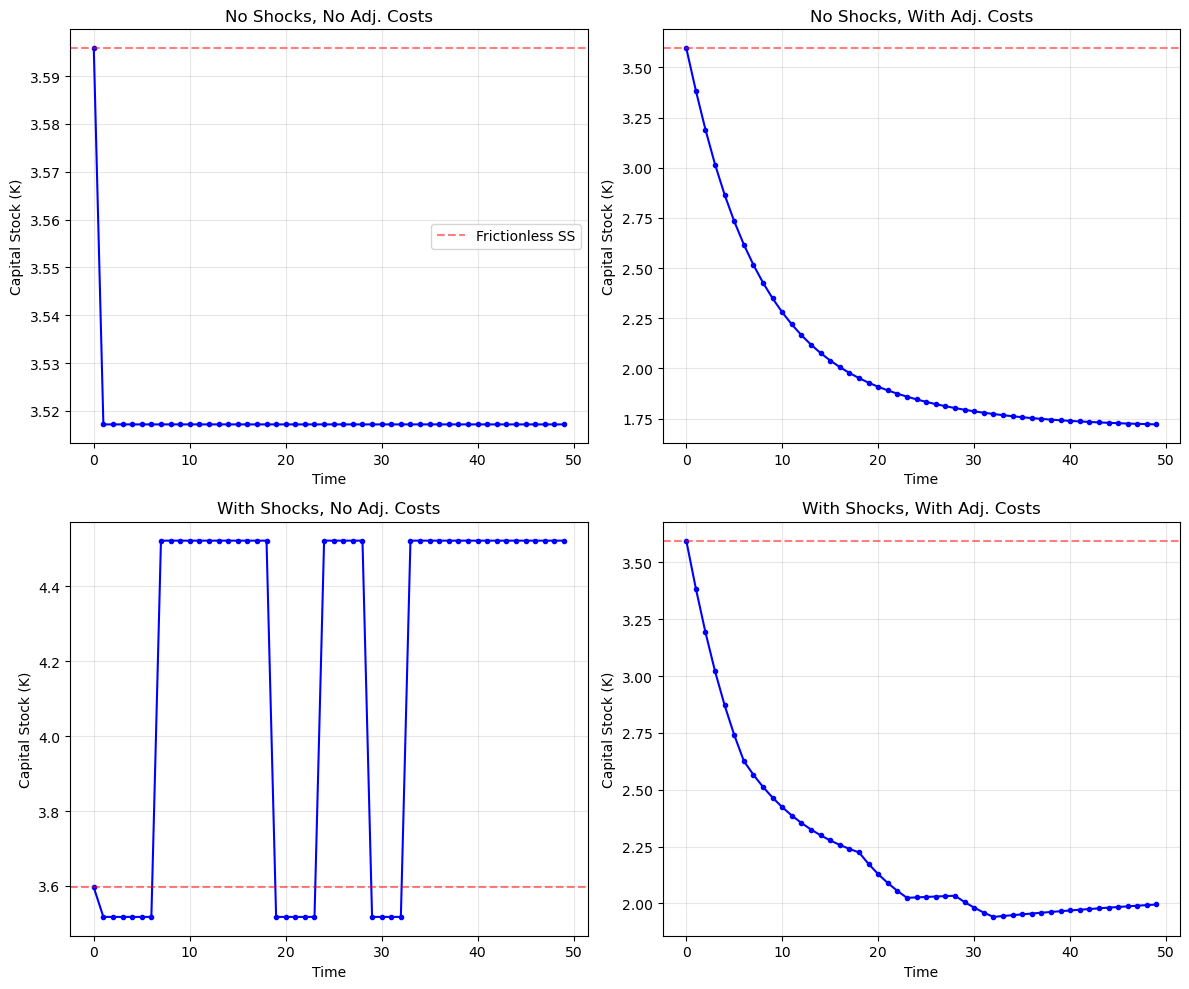

In [6]:
run_comparison()

In [3]:
class ColorPalette:
    # Main Gradient (purple to yellow)
    deep_purple: str = "#2C1C45"
    plum: str = "#71305C"
    raspberry: str = "#B34E63"
    coral: str = "#E47B5D"
    golden: str = "#FDB659"
    lemon: str = "#F9F871"
    
    # Matching Gradient (purple to teal)
    navy: str = "#254072"
    ocean_blue: str = "#006798"
    cerulean: str = "#008EB3"
    turquoise: str = "#00B6C1"
    mint: str = "#48DCC4"
    
    # Spot Palette additions
    dusty_purple: str = "#5B4876"
    lavender: str = "#FBEAFF"
    teal: str = "#00C9A8"
    
    # Twisted Spot additions
    seafoam: str = "#C4FCF0"
    forest_teal: str = "#4C8076"

In [7]:
import matplotlib.pyplot as plt
# 1. Setup Parameters
params = investment_simulation.InvestmentParameters(
    KAPPA=0,
    SIGMA_EPS=0,
)

# 2. Instantiate and Solve
model = investment_simulation.RationalInvestmentSimulation(params)
model.solve(verbose=False)

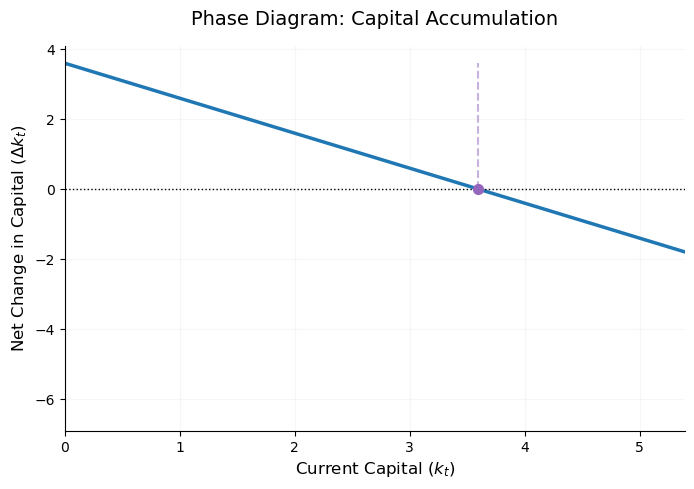

In [14]:
# --- RE-SOLVE WITH A WIDER RANGE ---
model.p.K_min = 0.000001
model.p.K_max = 10.0
model.p.N_k = 1000  
model.setup_grids()   

# *** THE FIX: Resize the matrices to match the new grid ***
model.initialize_value_function() 

model.solve()         

# --- PREPARE DATA ---
# (Rest of the code remains the same)
k_grid = model.k_grid
z_idx = model.actual_nz // 2
net_inv = model.policy_k[z_idx] - k_grid

# --- PREPARE DATA ---
k_grid = model.k_grid
z_idx = model.actual_nz // 2
net_inv = model.policy_k[z_idx] - k_grid

# Find steady state for plotting
from scipy.interpolate import interp1d
from scipy.optimize import brentq
net_inv_func = interp1d(k_grid, net_inv, kind='cubic')
try:
    k_ss = brentq(net_inv_func, k_grid[0], k_grid[-1])
except ValueError:
    k_ss = 0

# --- PLOT ---
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the curve
ax.plot(k_grid, net_inv, color='#1f77b4', linewidth=2.5, label=r'Net Investment $\Delta k$')

# Add the Zero Line
ax.axhline(0, color='black', linestyle=':', linewidth=1)

# Add the Steady State Marker
ax.scatter(k_ss, 0, color='#9467bd', s=50, zorder=5)
ax.vlines(k_ss, 0, np.max(net_inv), linestyles='--', colors='#9467bd', alpha=0.5)

# --- KEY CHANGE: Zoom out to see the start ---
# We cap the X-axis slightly past steady state to keep the focus on the shape
ax.set_xlim(0, k_ss * 1.5) 

# Labels
ax.set_title("Phase Diagram: Capital Accumulation", fontsize=14, pad=15)
ax.set_xlabel(r"Current Capital ($k_t$)", fontsize=12)
ax.set_ylabel(r"Net Change in Capital ($\Delta k_t$)", fontsize=12)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.1)

plt.show()

ValueError: x and y must have same first dimension, but have shapes (100,) and (1, 100)

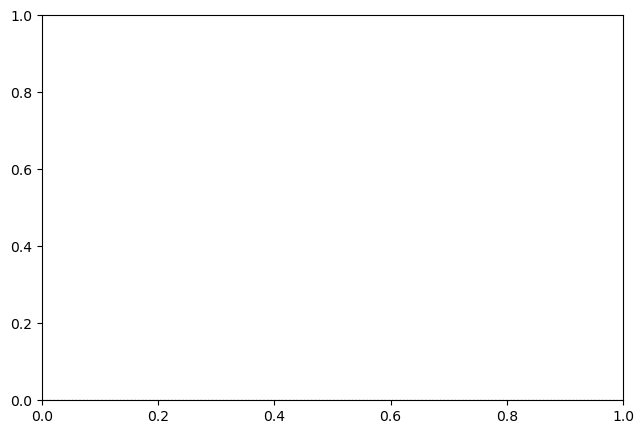

In [ ]:


# Use raw strings (r"...") to avoid SyntaxWarnings with LaTeX backslashes


# 4. LIMITS & AXES
x_lim = 17
y_max = np.max(net_inv_high) * 1.3
y_min = np.min(net_inv_low) * 1.3
plt.xlim([0, x_lim])
plt.ylim([y_min, y_max])

ax = plt.gca()
# Tiki Arrows
ax.annotate('', xy=(x_lim, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black', shrinkA=0, shrinkB=0),
            clip_on=False)
ax.annotate('', xy=(0, y_max), xytext=(0, y_min),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black', shrinkA=0, shrinkB=0),
            clip_on=False)

# 5. STABILITY ARROWS
plt.annotate('', xy=(k_ss*0.7, inv_func(k_ss*0.7)), xytext=(k_ss*0.4, inv_func(k_ss*0.4)),
             arrowprops=dict(arrowstyle='->', lw=2, color=ColorPalette.forest_teal))
plt.annotate('', xy=(k_ss*1.3, inv_func(k_ss*1.3)), xytext=(k_ss*1.6, inv_func(k_ss*1.6)),
             arrowprops=dict(arrowstyle='->', lw=2, color=ColorPalette.forest_teal))

# 6. STEADY STATE MARKER
plt.scatter(k_ss, 0, color=ColorPalette.dusty_purple, s=30, zorder=5)
plt.text(k_ss, y_min*0.3, r"$k^* \approx " + f"{k_ss:.2f}" + r"$", ha='center', fontsize=10)

# 7. LABELS - Note the 'r' prefix
plt.xlabel(r"$k_t$", loc='right', labelpad=-15)
plt.ylabel(r"$\Delta k_t$", loc='top', rotation=0, labelpad=-25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.set_xticks([])
ax.set_yticks([])

plt.legend(frameon=False, loc='upper right')

# Avoid tight_layout() if it crashes; use bbox_inches in savefig instead
# plt.savefig("investment_policy.pgf", backend='pgf', bbox_inches='tight')
plt.show()